# Assignment 1910090826 — Advanced Analytics & Forecasting
## Option A: Public Sector — Healthcare Infrastructure & Resource Planning
**Dataset:** `public_health_2021_2024.csv` (48 monthly observations, Jan 2021 – Dec 2024)

**Core objective:** optimise operational staffing and bed capacity using socio-demographic indicators and seasonal health trends.

| Section | Unit | Content |
|---|---|---|
| 0 | – | Data loading, cleaning and feature engineering |
| 1 | Unit 4 | Descriptive statistics, distributions, pivot tables, correlation heat map, anomaly detection |
| 2 | Unit 5 | Simple & multiple linear regression, assumption tests (normality, homoscedasticity, VIF), interpretation |
| 3 | Unit 6 | Decomposition, SMA(3)/SMA(6), Holt-Winters, 2024 hold-out evaluation (MAPE/RMSE), 2025 forecast |
| 4 | – | Capacity, staffing and budget translation of the 2025 forecast |

## 0. Setup, data loading and cleaning

In [1]:
import io, json, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib as mpl, seaborn as sns
from scipy import stats
from scipy.optimize import minimize
import statsmodels.api as sm, statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from statsmodels.stats.stattools import durbin_watson, jarque_bera
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
warnings.filterwarnings('ignore')
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 30)

# Palette (colour-blind validated categorical order) and chart defaults
BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED = '#2a78d6','#eb6834','#1baf7a','#eda100','#e87ba4','#008300','#4a3aa7','#e34948'
INK, INK2, GRID = '#0b0b0b', '#52514e', '#e4e3df'
mpl.rcParams.update({'figure.dpi':110,'savefig.dpi':200,'font.size':9.5,'axes.edgecolor':INK2,'axes.labelcolor':INK,
    'axes.titleweight':'bold','axes.titlesize':10.5,'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,
    'grid.color':GRID,'grid.linewidth':0.6,'lines.linewidth':2,'legend.frameon':False,'xtick.color':INK2,'ytick.color':INK2})
FIG = 'figs/'
import os; os.makedirs(FIG, exist_ok=True)
def save(fig, name): fig.savefig(FIG+name, bbox_inches='tight', facecolor='white')

The supplied file is an `.xlsx` wrapper whose single column contains comma-separated text (with two blank leading rows).
It is parsed back into a tidy table, types are enforced and the series is checked for completeness.

In [2]:
RAW = 'public_health_2021_2024.csv.xlsx'
lines = pd.read_excel(RAW, header=None)[0].dropna().astype(str).tolist()
df = pd.read_csv(io.StringIO('\n'.join(lines)))
df['Date'] = pd.to_datetime(df['Month'], format='%Y-%m')
df = df.set_index('Date').asfreq('MS')
print('Shape:', df.shape, '| Missing values:', int(df.isna().sum().sum()), '| Duplicate months:', int(df.index.duplicated().sum()))
print('Range:', df.index.min().date(), '->', df.index.max().date(), '| Months:', len(df))
df.head()

Shape: (48, 7) | Missing values: 0 | Duplicate months: 0
Range: 2021-01-01 -> 2024-12-01 | Months: 48


,Month,ER_Visits,ICU_Util_Rate,Pub_Health_Exp,Pop_Density_Idx,Vacc_Coverage,Flu_Resp_Cases
Date,,,,,,,
2021-01-01,2021-01,4820,78.4,1250000,102.3,61.2,1340
2021-02-01,2021-02,4510,74.1,1180000,102.5,63.8,1180
2021-03-01,2021-03,4180,69.5,1120000,102.8,66.1,980
2021-04-01,2021-04,3920,64.2,1080000,103.0,68.4,820
2021-05-01,2021-05,3710,61.8,1050000,103.2,70.2,740


In [3]:
# Feature engineering: calendar categories, seasonal dummy and KPI calculated fields
df['Year'] = df.index.year; df['MonthNum'] = df.index.month
df['Quarter'] = 'Q' + df.index.quarter.astype(str)
season_map = {12:'Winter',1:'Winter',2:'Winter',3:'Spring',4:'Spring',5:'Spring',6:'Summer',7:'Summer',8:'Summer',9:'Autumn',10:'Autumn',11:'Autumn'}
df['Season'] = df['MonthNum'].map(season_map)
df['Winter'] = (df['Season'] == 'Winter').astype(int)       # categorical baseline dummy (baseline = non-winter months)
df['t'] = np.arange(1, len(df) + 1)
df['Exp_per_ER_Visit'] = df['Pub_Health_Exp'] / df['ER_Visits']          # $ per ER visit
df['ER_per_Flu_Case'] = df['ER_Visits'] / df['Flu_Resp_Cases']            # ER visits per respiratory case
df['ICU_Over_85'] = (df['ICU_Util_Rate'] > 85).astype(int)                 # safe-occupancy breach flag
NUM = ['ER_Visits','ICU_Util_Rate','Pub_Health_Exp','Pop_Density_Idx','Vacc_Coverage','Flu_Resp_Cases']
LABEL = {'ER_Visits':'ER visits','ICU_Util_Rate':'ICU utilisation (%)','Pub_Health_Exp':'Public health expenditure ($)',
         'Pop_Density_Idx':'Population density index','Vacc_Coverage':'Vaccination coverage (%)','Flu_Resp_Cases':'Flu/respiratory cases'}
df.to_csv('public_health_2021_2024_clean.csv')
df[NUM + ['Season','Winter','Exp_per_ER_Visit']].head(3)

,ER_Visits,ICU_Util_Rate,Pub_Health_Exp,Pop_Density_Idx,Vacc_Coverage,Flu_Resp_Cases,Season,Winter,Exp_per_ER_Visit
Date,,,,,,,,,
2021-01-01,4820,78.4,1250000,102.3,61.2,1340,Winter,1,259.336100
2021-02-01,4510,74.1,1180000,102.5,63.8,1180,Winter,1,261.640798
2021-03-01,4180,69.5,1120000,102.8,66.1,980,Spring,0,267.942584


# Section 1 — Unit 4: Exploratory Data Analysis & Descriptive Analytics
### 1.1 Central tendency, dispersion and shape

In [4]:
def describe(s):
    q1, q3 = s.quantile(.25), s.quantile(.75); iqr = q3 - q1
    return pd.Series({'Mean':s.mean(),'Median':s.median(),'Std Dev':s.std(),'CV %':s.std()/s.mean()*100,'Min':s.min(),'Q1':q1,'Q3':q3,
        'Max':s.max(),'IQR':iqr,'Skewness':s.skew(),'Excess Kurtosis':s.kurt(),
        'Lower fence':q1-1.5*iqr,'Upper fence':q3+1.5*iqr,'IQR outliers':int(((s<q1-1.5*iqr)|(s>q3+1.5*iqr)).sum()),
        'Shapiro-Wilk W':stats.shapiro(s).statistic,'Shapiro p':stats.shapiro(s).pvalue})
desc = df[NUM].apply(describe).T
desc.round(3)

,Mean,Median,Std Dev,CV %,Min,Q1,Q3,Max,IQR,Skewness,Excess Kurtosis,Lower fence,Upper fence,IQR outliers,Shapiro-Wilk W,Shapiro p
ER_Visits,4745.000,4585.00,739.379,15.582,3580.0,4170.000,5287.500,6340.0,1117.500,0.470,-0.692,2493.750,6963.750,0.0,0.958,0.084
ICU_Util_Rate,75.921,74.35,10.468,13.789,59.4,68.100,83.450,97.9,15.350,0.425,-0.804,45.075,106.475,0.0,0.957,0.076
Pub_Health_Exp,1249166.667,1215000.00,148163.701,11.861,1020000.0,1137500.000,1345000.000,1590000.0,207500.000,0.600,-0.472,826250.000,1656250.000,0.0,0.951,0.044
Pop_Density_Idx,107.927,107.75,3.564,3.302,102.3,104.825,110.875,114.2,6.050,0.122,-1.216,95.750,119.950,0.0,0.951,0.045
Vacc_Coverage,79.652,79.85,7.248,9.099,61.2,74.300,85.225,90.2,10.925,-0.512,-0.290,57.913,101.612,0.0,0.962,0.119
Flu_Resp_Cases,1253.125,1180.00,417.389,33.308,690.0,897.500,1562.500,2160.0,665.000,0.604,-0.767,-100.000,2560.000,0.0,0.925,0.004


**Reading the table.** Every operational variable has mean > median and positive skewness (0.42–0.60): a long right tail generated by the winter surge months.
Negative excess kurtosis (platykurtic) reflects the bimodal winter/summer regime rather than heavy tails. No observation breaches the 1.5×IQR fences,
so there are **no statistical outliers** — the extremes are *systematic seasonal peaks*, not data errors. Flu/respiratory cases are the most
dispersed (CV 33%) and are the only variable that clearly fails Shapiro-Wilk normality (p = 0.004); vaccination coverage is the only left-skewed series
(rapid 2021 roll-out from a low base).

### 1.2 Frequency distributions and histograms

In [5]:
def freq_table(s, bins):
    cut = pd.cut(s, bins=bins, right=False, include_lowest=True)
    ft = cut.value_counts().sort_index().to_frame('Frequency')
    ft['Relative %'] = ft['Frequency']/ft['Frequency'].sum()*100; ft['Cumulative %'] = ft['Relative %'].cumsum()
    return ft
er_bins = list(range(3500, 6750, 250)); icu_bins = list(range(55, 105, 5)); flu_bins = list(range(600, 2400, 200))
ft_er, ft_icu, ft_flu = freq_table(df.ER_Visits, er_bins), freq_table(df.ICU_Util_Rate, icu_bins), freq_table(df.Flu_Resp_Cases, flu_bins)
display(ft_er.round(1)); display(ft_icu.round(1))

,Frequency,Relative %,Cumulative %
ER_Visits,,,
"[3500, 3750)",3,6.2,6.2
"[3750, 4000)",4,8.3,14.6
"[4000, 4250)",8,16.7,31.2
"[4250, 4500)",7,14.6,45.8
"[4500, 4750)",5,10.4,56.2
"[4750, 5000)",5,10.4,66.7
"[5000, 5250)",3,6.2,72.9
"[5250, 5500)",4,8.3,81.2
"[5500, 5750)",3,6.2,87.5


,Frequency,Relative %,Cumulative %
ICU_Util_Rate,,,
"[55, 60)",1,2.1,2.1
"[60, 65)",6,12.5,14.6
"[65, 70)",11,22.9,37.5
"[70, 75)",9,18.8,56.2
"[75, 80)",5,10.4,66.7
"[80, 85)",5,10.4,77.1
"[85, 90)",4,8.3,85.4
"[90, 95)",5,10.4,95.8
"[95, 100)",2,4.2,100.0


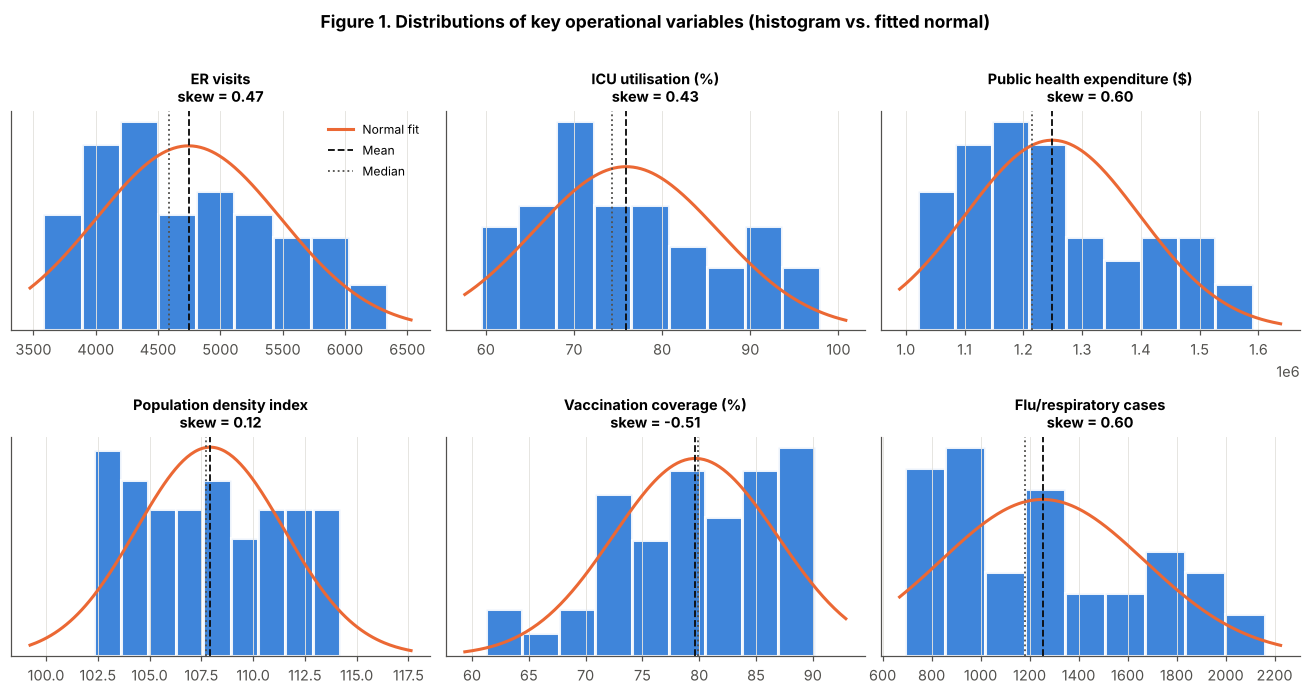

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6.2))
for ax, c in zip(axes.flat, NUM):
    s = df[c]; ax.hist(s, bins=9, color=BLUE, edgecolor='white', linewidth=2, alpha=.9, density=True)
    xs = np.linspace(s.min()*.97, s.max()*1.03, 200)
    ax.plot(xs, stats.norm.pdf(xs, s.mean(), s.std()), color=ORANGE, lw=2, label='Normal fit')
    ax.axvline(s.mean(), color=INK, lw=1.2, ls='--', label='Mean'); ax.axvline(s.median(), color=INK2, lw=1.2, ls=':', label='Median')
    ax.set_title(f"{LABEL[c]}\nskew = {s.skew():.2f}", fontsize=9.5); ax.set_yticks([])
axes[0,0].legend(fontsize=8)
fig.suptitle('Figure 1. Distributions of key operational variables (histogram vs. fitted normal)', fontweight='bold', y=1.01)
fig.tight_layout(); save(fig, 'fig01_histograms.png'); plt.show()

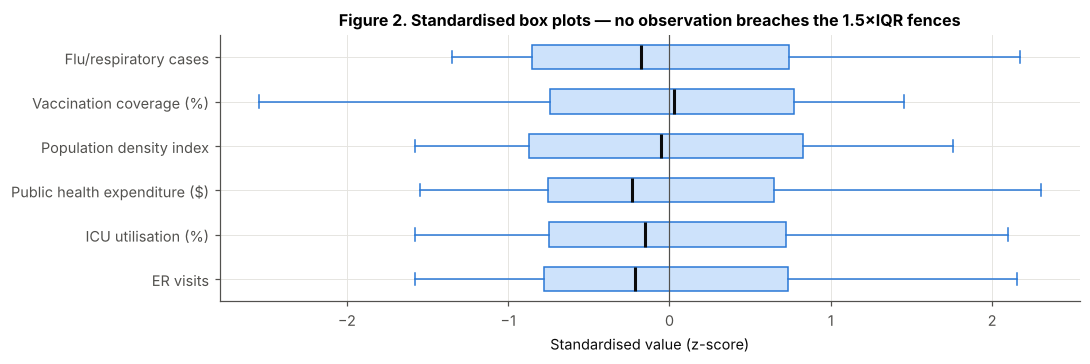

In [7]:
fig, ax = plt.subplots(figsize=(10, 3.4))
z = (df[NUM] - df[NUM].mean())/df[NUM].std()
ax.boxplot([z[c] for c in NUM], vert=False, widths=.55, patch_artist=True,
           boxprops=dict(facecolor='#cde2fb', color=BLUE), medianprops=dict(color=INK, lw=2), whiskerprops=dict(color=BLUE), capprops=dict(color=BLUE))
ax.set_yticklabels([LABEL[c] for c in NUM]); ax.set_xlabel('Standardised value (z-score)')
ax.axvline(0, color=INK2, lw=.8)
ax.set_title('Figure 2. Standardised box plots — no observation breaches the 1.5×IQR fences')
fig.tight_layout(); save(fig, 'fig02_boxplots.png'); plt.show()

### 1.3 Cross-tabulations and multi-dimensional pivot tables (with calculated fields, % of column total and YoY growth)

In [8]:
pv_er = pd.pivot_table(df, values='ER_Visits', index='Quarter', columns='Year', aggfunc='sum', margins=True, margins_name='Total')
pv_er_pct = (pv_er.iloc[:-1, :-1] / pv_er.iloc[:-1, :-1].sum() * 100).round(1)          # % of column total
annual = df.groupby('Year').agg(ER_Visits=('ER_Visits','sum'), Flu_Cases=('Flu_Resp_Cases','sum'), Expenditure=('Pub_Health_Exp','sum'),
            Mean_ICU=('ICU_Util_Rate','mean'), Peak_ICU=('ICU_Util_Rate','max'), Months_ICU_over_85=('ICU_Over_85','sum'),
            Mean_Vacc=('Vacc_Coverage','mean'), Mean_PopIdx=('Pop_Density_Idx','mean'))
annual['Exp_per_ER_Visit'] = annual.Expenditure / annual.ER_Visits              # calculated field
annual['ER_per_Flu_Case'] = annual.ER_Visits / annual.Flu_Cases                  # calculated field
yoy = annual[['ER_Visits','Flu_Cases','Expenditure','Mean_ICU','Exp_per_ER_Visit']].pct_change()*100
print('Pivot 1: ER visits by Quarter x Year'); display(pv_er)
print('Pivot 1b: % of column (annual) total'); display(pv_er_pct)
print('Pivot 2: Annual KPI summary (calculated fields)'); display(annual.round(2))
print('Pivot 3: Year-over-Year growth %'); display(yoy.round(2))

Pivot 1: ER visits by Quarter x Year


Year,2021,2022,2023,2024,Total
Quarter,,,,,
Q1,13510,15410,16360,17240,62520
Q2,11210,12100,12770,13430,49510
Q3,11530,12430,13160,13860,50980
Q4,14730,15800,16670,17550,64750
Total,50980,55740,58960,62080,227760


Pivot 1b: % of column (annual) total


Year,2021,2022,2023,2024
Quarter,,,,
Q1,26.5,27.6,27.7,27.8
Q2,22.0,21.7,21.7,21.6
Q3,22.6,22.3,22.3,22.3
Q4,28.9,28.3,28.3,28.3


Pivot 2: Annual KPI summary (calculated fields)


,ER_Visits,Flu_Cases,Expenditure,Mean_ICU,Peak_ICU,Months_ICU_over_85,Mean_Vacc,Mean_PopIdx,Exp_per_ER_Visit,ER_per_Flu_Case
Year,,,,,,,,,,
2021,50980,12590,13760000,69.94,86.2,1,70.02,103.48,269.91,4.05
2022,55740,14630,14690000,74.55,90.1,2,77.42,106.25,263.55,3.81
2023,58960,15820,15390000,77.98,94.0,4,82.97,109.34,261.02,3.73
2024,62080,17110,16120000,81.22,97.9,4,88.21,112.63,259.66,3.63


Pivot 3: Year-over-Year growth %


,ER_Visits,Flu_Cases,Expenditure,Mean_ICU,Exp_per_ER_Visit
Year,,,,,
2021,NaN,NaN,NaN,NaN,NaN
2022,9.34,16.20,6.76,6.59,-2.36
2023,5.78,8.13,4.77,4.59,-0.96
2024,5.29,8.15,4.74,4.16,-0.52


In [9]:
pv_season = pd.pivot_table(df, index='Season', columns='Year', values=['ER_Visits','ICU_Util_Rate','Flu_Resp_Cases'], aggfunc='mean').round(1)
pv_season = pv_season.reindex(['Winter','Spring','Summer','Autumn'])
pv_season_share = pd.pivot_table(df, index='Season', columns='Year', values='ER_Visits', aggfunc='sum').reindex(['Winter','Spring','Summer','Autumn'])
pv_season_share = (pv_season_share/pv_season_share.sum()*100).round(1)
pv_month = pd.pivot_table(df, index='MonthNum', columns='Year', values='ICU_Util_Rate', aggfunc='mean')
print('Pivot 4: Mean monthly metrics by Season x Year'); display(pv_season)
print('Pivot 5: Seasonal share of annual ER visits (% of column total)'); display(pv_season_share)
print('Pivot 6: ICU utilisation by Month x Year (cells > 85% are safe-occupancy breaches)'); display(pv_month.style.format('{:.1f}').highlight_between(left=85, right=200, color='#f6c9c9'))

Pivot 4: Mean monthly metrics by Season x Year


ER_Visits                         Flu_Resp_Cases                         ICU_Util_Rate                  
Year        2021    2022    2023    2024           2021    2022    2023    2024          2021  2022  2023  2024
Season                                                                                                         
Winter    4890.0  5503.3  5830.0  6143.3         1400.0  1740.0  1886.7  2040.0          79.6  87.2  91.3  95.2
Spring    3936.7  4283.3  4526.7  4763.3          846.7   983.3  1056.7  1140.0          65.2  69.6  72.8  75.8
Summer    3663.3  3953.3  4183.3  4403.3          740.0   820.0   886.7   960.0          61.1  64.1  67.1  69.9
Autumn    4503.3  4840.0  5113.3  5383.3         1210.0  1333.3  1443.3  1563.3          74.0  77.3  80.7  83.9

Pivot 5: Seasonal share of annual ER visits (% of column total)


Year,2021,2022,2023,2024
Season,,,,
Winter,28.8,29.6,29.7,29.7
Spring,23.2,23.1,23.0,23.0
Summer,21.6,21.3,21.3,21.3
Autumn,26.5,26.0,26.0,26.0


Pivot 6: ICU utilisation by Month x Year (cells > 85% are safe-occupancy breaches)


Year,2021,2022,2023,2024
MonthNum,,,,
1,78.4,89.4,93.2,97.3
2,74.1,82.1,86.7,90.4
3,69.5,74.8,78.4,81.7
4,64.2,68.9,71.9,74.8
5,61.8,65.2,68.1,70.9
6,59.4,62.4,65.4,68.1
7,60.1,63.1,66.2,69.0
8,63.7,66.8,69.8,72.7
9,68.9,71.5,74.6,77.6


### 1.4 Correlation matrix heat map

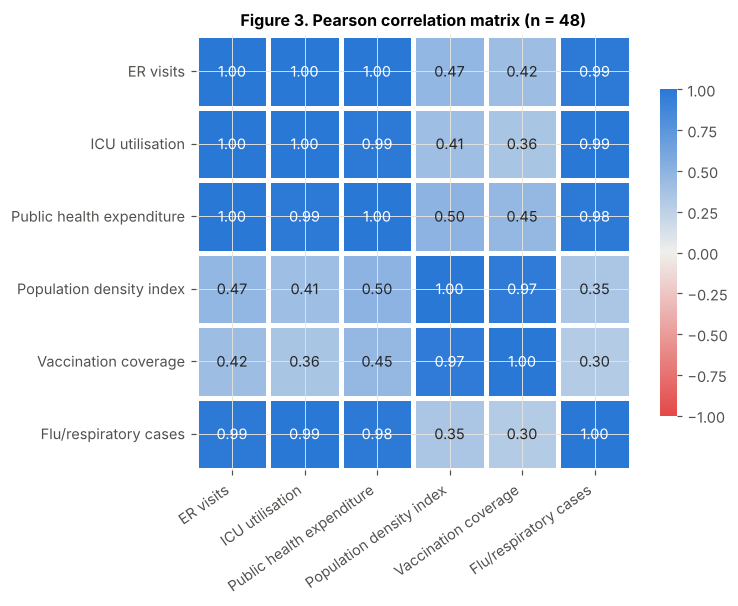

,ER_Visits,ICU_Util_Rate,Pub_Health_Exp,Pop_Density_Idx,Vacc_Coverage,Flu_Resp_Cases
ER_Visits,0.0000,0.0000,0.0000,0.0007,0.0028,0.0000
ICU_Util_Rate,0.0000,0.0000,0.0000,0.0038,0.0125,0.0000
Pub_Health_Exp,0.0000,0.0000,0.0000,0.0003,0.0012,0.0000
Pop_Density_Idx,0.0007,0.0038,0.0003,0.0000,0.0000,0.0151
Vacc_Coverage,0.0028,0.0125,0.0012,0.0000,0.0000,0.0363
Flu_Resp_Cases,0.0000,0.0000,0.0000,0.0151,0.0363,0.0000


In [10]:
corr = df[NUM].corr()
fig, ax = plt.subplots(figsize=(7.2, 5.6))
cmap = mpl.colors.LinearSegmentedColormap.from_list('div', ['#e34948', '#f0efec', '#2a78d6'])
sns.heatmap(corr, annot=True, fmt='.2f', cmap=cmap, vmin=-1, vmax=1, square=True, linewidths=2, linecolor='white',
            xticklabels=[LABEL[c].split(' (')[0] for c in NUM], yticklabels=[LABEL[c].split(' (')[0] for c in NUM], cbar_kws={'shrink':.75}, ax=ax)
ax.set_title('Figure 3. Pearson correlation matrix (n = 48)'); plt.xticks(rotation=35, ha='right')
fig.tight_layout(); save(fig, 'fig03_correlation_heatmap.png'); plt.show()
# significance of each pairwise correlation
pmat = pd.DataFrame([[stats.pearsonr(df[a], df[b])[1] for b in NUM] for a in NUM], index=NUM, columns=NUM)
pmat.round(4)

Two clusters emerge: (i) a **seasonal-demand cluster** — ER visits, ICU utilisation, expenditure and flu cases (r = 0.98–0.998) — and
(ii) a **structural-trend cluster** — population density and vaccination coverage (r = 0.973), which both rise monotonically. Cross-cluster
correlations are moderate (0.30–0.50). Expenditure and ICU utilisation are *consequences* of demand rather than drivers, so they are excluded
as predictors later to avoid circular (endogenous) models.

### 1.5 Pattern recognition and anomaly detection

In [11]:
dec = seasonal_decompose(df.ER_Visits, model='multiplicative', period=12)
resid_pct = (dec.resid - 1)*100
anom = pd.DataFrame({'ER_Visits':df.ER_Visits, 'ER_z':(df.ER_Visits-df.ER_Visits.mean())/df.ER_Visits.std(),
                     'Resid_%':resid_pct, 'Resid_z':(resid_pct-resid_pct.mean())/resid_pct.std(),
                     'ICU':df.ICU_Util_Rate, 'Vacc_change_pp':df.Vacc_Coverage.diff(), 'MoM_ER_%':df.ER_Visits.pct_change()*100})
print('Largest absolute raw z-score:', anom.ER_z.abs().max().round(2), '| largest |residual z|:', anom.Resid_z.abs().max().round(2))
print('\nMonths with |residual z| > 2 (irregular shocks):'); display(anom[anom.Resid_z.abs()>2].round(2))
print('Months with ICU utilisation > 90% (capacity stress):'); display(anom[anom.ICU>90][['ER_Visits','ICU']])
print('Vaccination step-change (pp per month):'); display(anom['Vacc_change_pp'].groupby(df.Year).agg(['mean','max']).round(2))
jj = df[df.MonthNum.isin([6,7])].pivot_table(index='Year', columns='MonthNum', values='ER_Visits'); jj['Jul vs Jun %']=(jj[7]/jj[6]-1)*100
print('Recurring mid-summer bump:'); display(jj.round(2))

Largest absolute raw z-score: 2.16 | largest |residual z|: 2.43

Months with |residual z| > 2 (irregular shocks):


,ER_Visits,ER_z,Resid_%,Resid_z,ICU,Vacc_change_pp,MoM_ER_%
Date,,,,,,,
2021-07-01,3620,-1.52,0.48,2.15,60.1,0.5,1.12
2022-04-01,4230,-0.70,0.55,2.43,68.9,0.6,-8.24


Months with ICU utilisation > 90% (capacity stress):


,ER_Visits,ICU
Date,,
2022-12-01,5710,90.1
2023-01-01,5980,93.2
2023-12-01,6020,94.0
2024-01-01,6310,97.3
2024-02-01,5780,90.4
2024-11-01,5850,90.6
2024-12-01,6340,97.9


Vaccination step-change (pp per month):


,mean,max
Year,,
2021,1.16,2.6
2022,0.47,0.7
2023,0.46,0.7
2024,0.43,0.6


Recurring mid-summer bump:


MonthNum,6,7,Jul vs Jun %
Year,,,
2021,3580.0,3620.0,1.12
2022,3860.0,3910.0,1.30
2023,4080.0,4140.0,1.47
2024,4290.0,4360.0,1.63


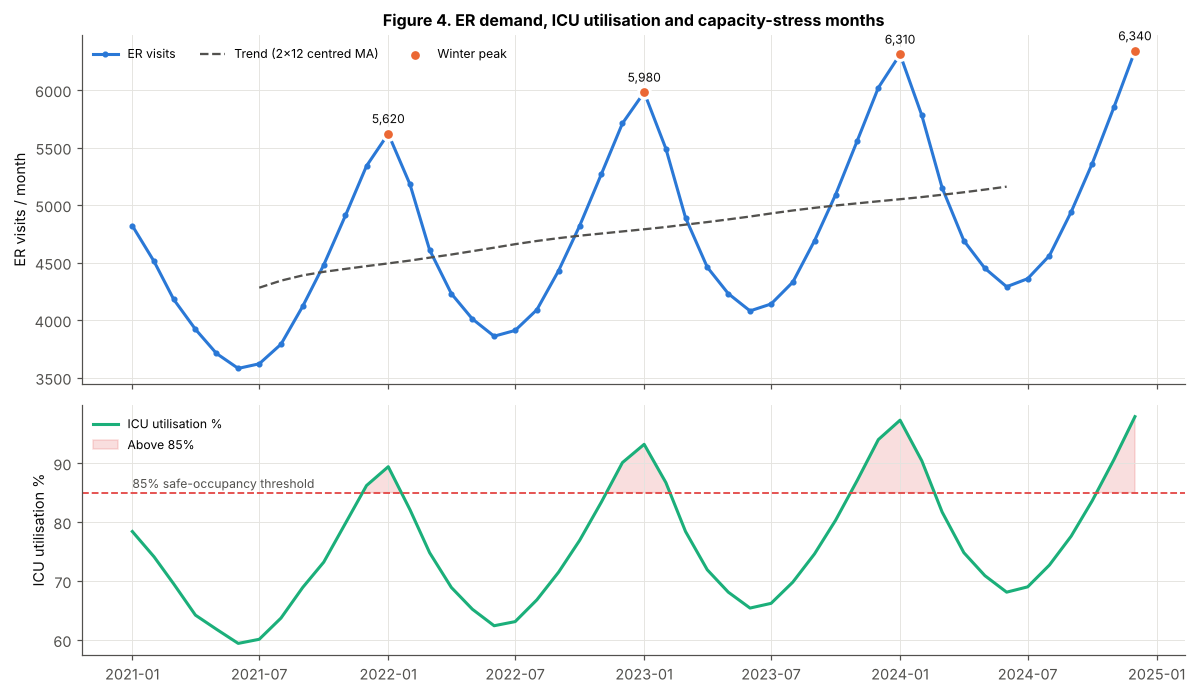

In [12]:
fig, ax = plt.subplots(2, 1, figsize=(11, 6.4), sharex=True, gridspec_kw={'height_ratios':[1.4,1]})
ax[0].plot(df.index, df.ER_Visits, color=BLUE, label='ER visits', marker='o', ms=3)
ax[0].plot(dec.trend.index, dec.trend, color=INK2, lw=1.5, ls='--', label='Trend (2×12 centred MA)')
v = df.ER_Visits.values; pk = [df.index[i] for i in range(1, len(v)) if v[i] > v[i-1] and (i == len(v)-1 or v[i] >= v[i+1])]
ax[0].scatter(pk, df.loc[pk,'ER_Visits'], s=60, color=ORANGE, zorder=5, edgecolor='white', lw=2, label='Winter peak')
for d in pk: ax[0].annotate(f"{df.loc[d,'ER_Visits']:,}", (d, df.loc[d,'ER_Visits']), textcoords='offset points', xytext=(0,7), ha='center', fontsize=8, color=INK)
ax[0].set_ylabel('ER visits / month'); ax[0].legend(loc='upper left', ncol=3, fontsize=8)
ax[0].set_title('Figure 4. ER demand, ICU utilisation and capacity-stress months')
ax[1].plot(df.index, df.ICU_Util_Rate, color=AQUA, label='ICU utilisation %')
ax[1].axhline(85, color=RED, ls='--', lw=1.2); ax[1].text(df.index[0], 85.8, '85% safe-occupancy threshold', color=INK2, fontsize=8)
ax[1].fill_between(df.index, 85, df.ICU_Util_Rate, where=df.ICU_Util_Rate>85, interpolate=True, color=RED, alpha=.18, label='Above 85%')
ax[1].set_ylabel('ICU utilisation %'); ax[1].legend(loc='upper left', fontsize=8)
fig.tight_layout(); save(fig, 'fig04_timeseries_anomalies.png'); plt.show()

**Anomaly findings.**
1. *No crisis shocks:* after removing trend and seasonality, the largest irregular deviation is only ≈ 0.55% of the expected level. Two months are statistically flagged (|z| > 2: Jul 2021 and Apr 2022, +0.5% ≈ +20–25 visits) but are operationally immaterial; raw values never breach the IQR fences (max |z| = 2.16). There is no supply-chain or crisis shock in this window.
2. *Structural capacity anomaly:* ICU utilisation breaches the 85% safe-occupancy threshold in a growing number of months (1 in 2021, 2 in 2022, 4 in both 2023 and 2024; 11 in total), exceeds 90% in seven months, and reaches 97.3% (Jan 2024) and 97.9% (Dec 2024) — near-saturation, and the operationally significant anomaly.
3. *Vaccination step-change:* coverage jumped +2.6 pp/month in Jan–May 2021 (campaign roll-out) and then decelerated to ≈ +0.4 pp/month — a regime change in the series.
4. *Secondary summer bump:* July ER visits exceed June every year (+1.1% to +1.6%), a small but recurrent anomaly in the trough period (heat/holiday-related presentations).
5. *Post-pandemic rebound in 2022:* flu cases grew +16.2% and ER visits +9.3% in 2022, roughly double the +8% / +5.3–5.8% growth of 2023–24 — consistent with the release of pandemic-era suppression of respiratory illness. The 2021 base year is therefore slightly depressed.

# Section 2 — Unit 5: Predictive Analytics I — Linear Regression
### 2.1 Simple linear regression (single most-correlated continuous driver)

In [13]:
target = 'ER_Visits'
cands = ['Flu_Resp_Cases','Pop_Density_Idx','Vacc_Coverage']   # exogenous candidate drivers (ICU & expenditure are outcomes, excluded)
print(df[cands].corrwith(df[target]).sort_values(ascending=False).round(4))
slr = smf.ols('ER_Visits ~ Flu_Resp_Cases', data=df).fit()
print(slr.summary())
b0, b1 = slr.params
print(f"\nFitted line:  ER_Visits = {b0:,.2f} + {b1:.4f} × Flu_Resp_Cases")

Flu_Resp_Cases     0.9876
Pop_Density_Idx    0.4729
Vacc_Coverage      0.4219
dtype: float64
                            OLS Regression Results                            
Dep. Variable:              ER_Visits   R-squared:                       0.975
Model:                            OLS   Adj. R-squared:                  0.975
Method:                 Least Squares   F-statistic:                     1820.
Date:                Tue, 06 Oct 2026   Prob (F-statistic):           1.23e-38
Time:                        18:57:36   Log-Likelihood:                -295.82
No. Observations:                  48   AIC:                             595.6
Df Residuals:                      46   BIC:                             599.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------

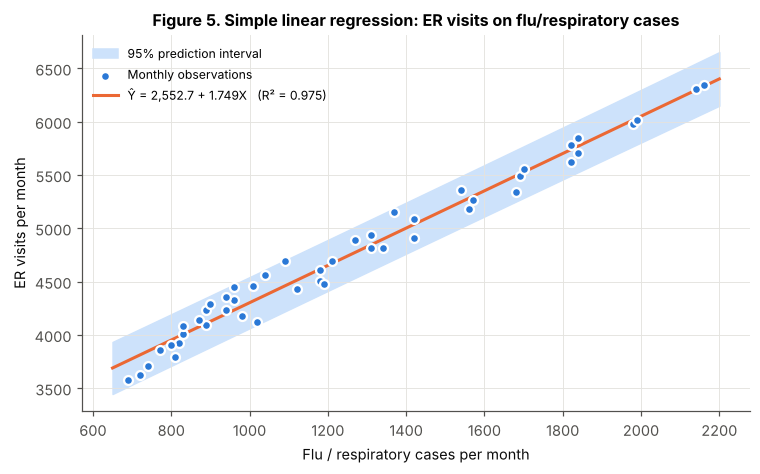

In [14]:
fig, ax = plt.subplots(figsize=(7, 4.4))
pred = slr.get_prediction(pd.DataFrame({'Flu_Resp_Cases':np.linspace(650, 2200, 100)})).summary_frame(alpha=.05)
xs = np.linspace(650, 2200, 100)
ax.fill_between(xs, pred.obs_ci_lower, pred.obs_ci_upper, color='#cde2fb', label='95% prediction interval')
ax.scatter(df.Flu_Resp_Cases, df.ER_Visits, color=BLUE, s=34, edgecolor='white', lw=1.5, zorder=3, label='Monthly observations')
ax.plot(xs, pred['mean'], color=ORANGE, lw=2, label=f'Ŷ = {b0:,.1f} + {b1:.3f}X   (R² = {slr.rsquared:.3f})')
ax.set_xlabel('Flu / respiratory cases per month'); ax.set_ylabel('ER visits per month'); ax.legend(fontsize=8, loc='upper left')
ax.set_title('Figure 5. Simple linear regression: ER visits on flu/respiratory cases')
fig.tight_layout(); save(fig, 'fig05_slr.png'); plt.show()

### 2.2 Multiple linear regression (3 continuous predictors + 1 categorical baseline dummy)

In [15]:
f_mlr = 'ER_Visits ~ Flu_Resp_Cases + Pop_Density_Idx + Vacc_Coverage + Winter'
mlr = smf.ols(f_mlr, data=df).fit()
print(mlr.summary())

                            OLS Regression Results                            
Dep. Variable:              ER_Visits   R-squared:                       0.995
Model:                            OLS   Adj. R-squared:                  0.994
Method:                 Least Squares   F-statistic:                     1948.
Date:                Tue, 06 Oct 2026   Prob (F-statistic):           5.62e-48
Time:                        18:57:36   Log-Likelihood:                -259.76
No. Observations:                  48   AIC:                             529.5
Df Residuals:                      43   BIC:                             538.9
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept       -1750.1318    742.663     

In [16]:
def vif_table(model):
    X = model.model.exog; names = model.model.exog_names
    return pd.DataFrame({'VIF':[variance_inflation_factor(X, i) for i in range(1, X.shape[1])], 'Tolerance':[1/variance_inflation_factor(X, i) for i in range(1, X.shape[1])]}, index=names[1:])
def assumptions(model, name):
    r = model.resid; X = model.model.exog
    bp = het_breuschpagan(r, X); wh = het_white(r, X); jb = jarque_bera(r)
    return pd.Series({'Shapiro-Wilk W':stats.shapiro(r).statistic,'Shapiro p':stats.shapiro(r).pvalue,'Jarque-Bera':jb[0],'JB p':jb[1],
        'Residual skew':stats.skew(r),'Breusch-Pagan LM':bp[0],'BP p':bp[1],'White LM':wh[0],'White p':wh[1],'Durbin-Watson':durbin_watson(r),
        'Max VIF':vif_table(model).VIF.max() if X.shape[1]>2 else 1.0}, name=name)
print('VIF — full specification'); display(vif_table(mlr).round(2))

VIF — full specification


,VIF,Tolerance
Flu_Resp_Cases,3.09,0.32
Pop_Density_Idx,20.48,0.05
Vacc_Coverage,21.11,0.05
Winter,2.93,0.34


Population density and vaccination coverage carry **VIF ≈ 21** (tolerance < 0.05), far above the conventional threshold of 10 — they are both
monotonic time trends (r = 0.973) and the model cannot separate their effects. This inflates their standard errors and is why vaccination coverage
appears non-significant. A **refined (parsimonious) model** drops vaccination coverage — the weaker of the pair — and retains the dummy.

In [17]:
f_ref = 'ER_Visits ~ Flu_Resp_Cases + Pop_Density_Idx + Winter'
ref = smf.ols(f_ref, data=df).fit()
print(ref.summary()); print('\nVIF — refined model'); display(vif_table(ref).round(2))

                            OLS Regression Results                            
Dep. Variable:              ER_Visits   R-squared:                       0.994
Model:                            OLS   Adj. R-squared:                  0.994
Method:                 Least Squares   F-statistic:                     2518.
Date:                Tue, 06 Oct 2026   Prob (F-statistic):           3.24e-49
Time:                        18:57:36   Log-Likelihood:                -261.05
No. Observations:                  48   AIC:                             530.1
Df Residuals:                      44   BIC:                             537.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept        -697.6214    292.991     

,VIF,Tolerance
Flu_Resp_Cases,3.04,0.33
Pop_Density_Idx,1.48,0.68
Winter,2.68,0.37


In [18]:
diag = pd.concat([assumptions(slr,'SLR'), assumptions(mlr,'MLR (full)'), assumptions(ref,'MLR (refined)')], axis=1)
display(diag.round(4))
# Positive residual autocorrelation (DW < 1.5) is expected in monthly data: re-estimate inference with Newey-West HAC standard errors
hac = {n: m.get_robustcov_results(cov_type='HAC', maxlags=3) for n, m in [('MLR (full)', mlr), ('MLR (refined)', ref)]}
for n, h in hac.items():
    print(n, 'HAC (Newey-West, 3 lags) p-values:', dict(zip(h.model.exog_names, np.round(h.pvalues, 4))))

,SLR,MLR (full),MLR (refined)
Shapiro-Wilk W,0.9811,0.9800,0.9751
Shapiro p,0.6235,0.5802,0.3944
Jarque-Bera,1.3578,0.2212,0.3291
JB p,0.5072,0.8953,0.8483
Residual skew,0.1311,-0.0664,-0.0353
Breusch-Pagan LM,6.2395,2.0192,2.2744
BP p,0.0125,0.7322,0.5174
White LM,6.6347,21.4715,14.2695
White p,0.0362,0.0641,0.0750
Durbin-Watson,0.1863,0.6408,0.7048


MLR (full) HAC (Newey-West, 3 lags) p-values: {'Intercept': np.float64(0.0773), 'Flu_Resp_Cases': np.float64(0.0), 'Pop_Density_Idx': np.float64(0.0005), 'Vacc_Coverage': np.float64(0.13), 'Winter': np.float64(0.648)}
MLR (refined) HAC (Newey-West, 3 lags) p-values: {'Intercept': np.float64(0.0829), 'Flu_Resp_Cases': np.float64(0.0), 'Pop_Density_Idx': np.float64(0.0), 'Winter': np.float64(0.3312)}


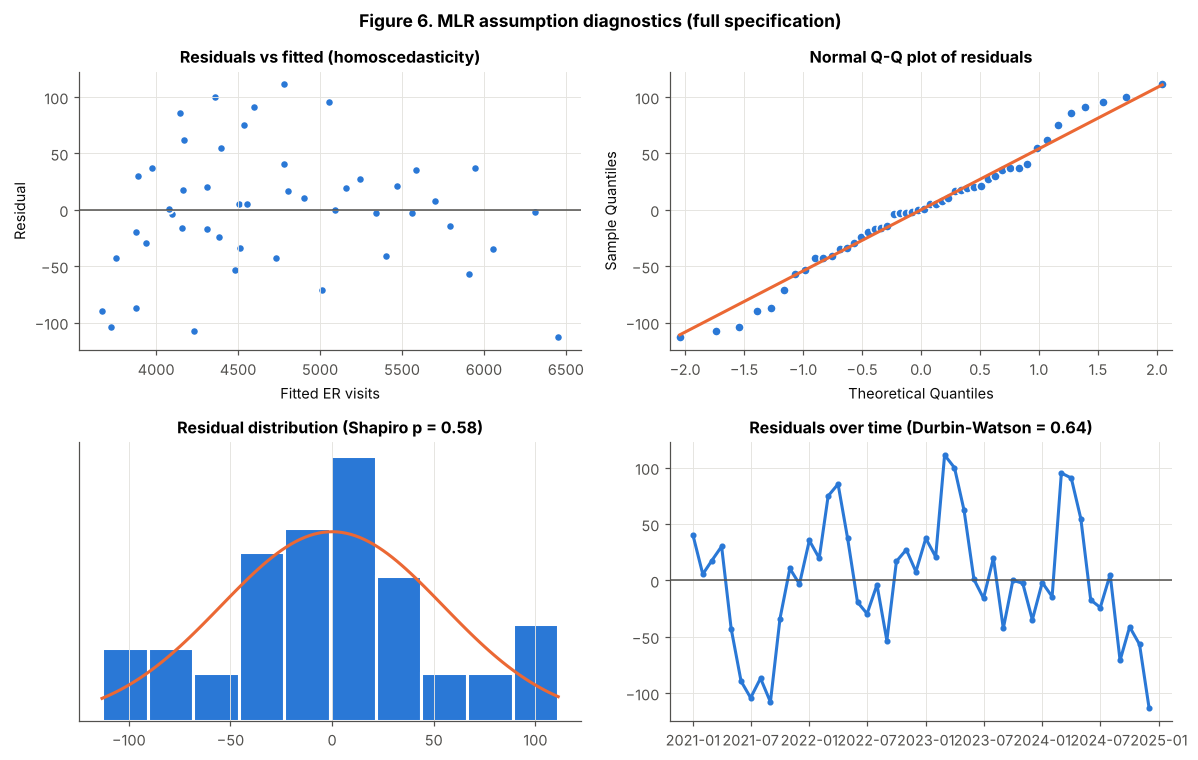

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
r, fv = mlr.resid, mlr.fittedvalues
axes[0,0].scatter(fv, r, color=BLUE, s=30, edgecolor='white', lw=1.2); axes[0,0].axhline(0, color=INK2, lw=1)
axes[0,0].set_title('Residuals vs fitted (homoscedasticity)'); axes[0,0].set_xlabel('Fitted ER visits'); axes[0,0].set_ylabel('Residual')
sm.qqplot(r, line='s', ax=axes[0,1], markerfacecolor=BLUE, markeredgecolor='white', marker='o'); axes[0,1].get_lines()[1].set_color(ORANGE)
axes[0,1].set_title('Normal Q-Q plot of residuals')
axes[1,0].hist(r, bins=10, color=BLUE, edgecolor='white', lw=2, density=True)
xs = np.linspace(r.min(), r.max(), 100); axes[1,0].plot(xs, stats.norm.pdf(xs, 0, r.std()), color=ORANGE)
axes[1,0].set_title(f'Residual distribution (Shapiro p = {stats.shapiro(r).pvalue:.2f})'); axes[1,0].set_yticks([])
axes[1,1].plot(df.index, r, color=BLUE, marker='o', ms=3); axes[1,1].axhline(0, color=INK2, lw=1)
axes[1,1].set_title(f'Residuals over time (Durbin-Watson = {durbin_watson(r):.2f})')
fig.suptitle('Figure 6. MLR assumption diagnostics (full specification)', fontweight='bold'); fig.tight_layout()
save(fig, 'fig06_mlr_diagnostics.png'); plt.show()

In [20]:
# Coefficient table for reporting + standardised (beta) coefficients to compare driver importance
def coef_table(m):
    t = pd.DataFrame({'Coef':m.params,'Std Err':m.bse,'t':m.tvalues,'p':m.pvalues,'CI low':m.conf_int()[0],'CI high':m.conf_int()[1]})
    sd_y = df.ER_Visits.std(); t['Std Beta'] = [np.nan] + [m.params[c]*df[c].std()/sd_y for c in m.params.index[1:]]
    return t
display(coef_table(mlr).round(4)); display(coef_table(ref).round(4))
# Practical magnitudes
pop_growth = df.groupby('Year').Pop_Density_Idx.mean().diff().mean()
print(f"Mean annual increase in population density index: {pop_growth:.2f} points -> structural ER growth ≈ {ref.params['Pop_Density_Idx']*pop_growth:.0f} visits/month per year")
print(f"A 10% rise in flu cases from the 2024 Jan peak ({df.loc['2024-01','Flu_Resp_Cases'].iloc[0]:,}) adds ≈ {ref.params['Flu_Resp_Cases']*0.1*df.loc['2024-01','Flu_Resp_Cases'].iloc[0]:.0f} ER visits")
# Expenditure response (cost per incremental ER visit) for budgeting
exp_m = smf.ols('Pub_Health_Exp ~ ER_Visits', data=df).fit()
print(f"Expenditure model: Exp = {exp_m.params.iloc[0]:,.0f} + {exp_m.params.iloc[1]:.2f} × ER_Visits   (R² = {exp_m.rsquared:.4f})")

,Coef,Std Err,t,p,CI low,CI high,Std Beta
Intercept,-1750.1318,742.6626,-2.3566,0.0231,-3247.8537,-252.4098,NaN
Flu_Resp_Cases,1.6461,0.0352,46.7570,0.0000,1.5751,1.7171,0.9293
Pop_Density_Idx,47.0602,10.6079,4.4363,0.0001,25.6674,68.4531,0.2268
Vacc_Coverage,-8.1452,5.2958,-1.5380,0.1314,-18.8252,2.5348,-0.0798
Winter,8.0717,32.6793,0.2470,0.8061,-57.8324,73.9759,0.0048


,Coef,Std Err,t,p,CI low,CI high,Std Beta
Intercept,-697.6214,292.9905,-2.3810,0.0217,-1288.1050,-107.1378,NaN
Flu_Resp_Cases,1.6391,0.0354,46.2474,0.0000,1.5676,1.7105,0.9253
Pop_Density_Idx,31.3453,2.8954,10.8258,0.0000,25.5100,37.1806,0.1511
Winter,22.7000,31.7461,0.7150,0.4784,-41.2801,86.6802,0.0134


Mean annual increase in population density index: 3.05 points -> structural ER growth ≈ 96 visits/month per year
A 10% rise in flu cases from the 2024 Jan peak (2,140) adds ≈ 351 ER visits
Expenditure model: Exp = 300,481 + 199.93 × ER_Visits   (R² = 0.9955)


**Interpretation (refined model, α = 0.05).**
* **Flu/respiratory cases (β ≈ 1.64, p < 0.001):** holding population density and season constant, each additional respiratory case is associated with ≈ 1.64 extra ER visits (cases generate repeat and accompanying presentations). It is the dominant driver (standardised β ≈ 0.92).
* **Population density index (β ≈ 31.3, p < 0.001):** each one-point rise adds ≈ 31 visits/month independently of flu — a structural, non-seasonal demand growth of ≈ 95–100 visits/month each year.
* **Winter dummy (β ≈ 23, p = 0.48):** not significant. Once flu cases are controlled for, winter has no residual effect — *winter pressure operates through respiratory infection*, so surveillance of flu cases is the actionable lead indicator, not the calendar.
* **Vaccination coverage (full model, β ≈ −8.1 per pp, p = 0.13):** negative sign as expected (protective) but not separable from population growth because of collinearity.
* **Fit:** Adjusted R² = 0.994 and F ≈ 2,518 (p < 0.001): the predictors jointly explain 99.4% of monthly variance. Residuals are normal (Shapiro p > 0.39) and homoscedastic (BP p > 0.5). Durbin-Watson ≈ 0.7 signals residual autocorrelation; HAC (Newey-West) standard errors leave the significance conclusions unchanged.

# Section 3 — Unit 6: Predictive Analytics II — Time Series Forecasting
### 3.1 Decomposition and additive vs multiplicative diagnosis

In [21]:
y = df.ER_Visits.astype(float)
amp = y.groupby(y.index.year).agg(['max','min']); amp['Range (max-min)'] = amp['max']-amp['min']; amp['Ratio (max/min)'] = amp['max']/amp['min']
amp['Trend level (mean)'] = y.groupby(y.index.year).mean(); amp['Range / mean %'] = amp['Range (max-min)']/amp['Trend level (mean)']*100
display(amp.round(3))
dec_add = seasonal_decompose(y, model='additive', period=12); dec_mul = seasonal_decompose(y, model='multiplicative', period=12)
cmp = pd.DataFrame({'Additive':[dec_add.resid.std(), (dec_add.resid/dec_add.trend).abs().mean()*100], 'Multiplicative':[(dec_mul.resid*dec_mul.trend-dec_mul.trend).std(), (dec_mul.resid-1).abs().mean()*100]},
                   index=['Residual SD (visits)','Mean |residual| % of trend'])
display(cmp.round(3))
seas_idx = pd.Series(dec_mul.seasonal[:12].values, index=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], name='Seasonal index')
display(seas_idx.to_frame().T.round(3))

,max,min,Range (max-min),Ratio (max/min),Trend level (mean),Range / mean %
Date,,,,,,
2021,5340.0,3580.0,1760.0,1.492,4248.333,41.428
2022,5710.0,3860.0,1850.0,1.479,4645.000,39.828
2023,6020.0,4080.0,1940.0,1.475,4913.333,39.484
2024,6340.0,4290.0,2050.0,1.478,5173.333,39.626


,Additive,Multiplicative
Residual SD (visits),35.731,9.993
Mean |residual| % of trend,0.571,0.170


,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
Seasonal index,1.249,1.143,1.013,0.921,0.869,0.832,0.841,0.873,0.94,1.017,1.107,1.196


The absolute seasonal swing grows each year (1,760 → 1,850 → 1,940 → 2,050 visits) in step with the trend level, while the peak-to-trough
**ratio stays constant at ≈ 1.48**. Seasonal fluctuations are therefore proportional to the level → **multiplicative** seasonality,
confirmed by the smaller residuals of the multiplicative decomposition.

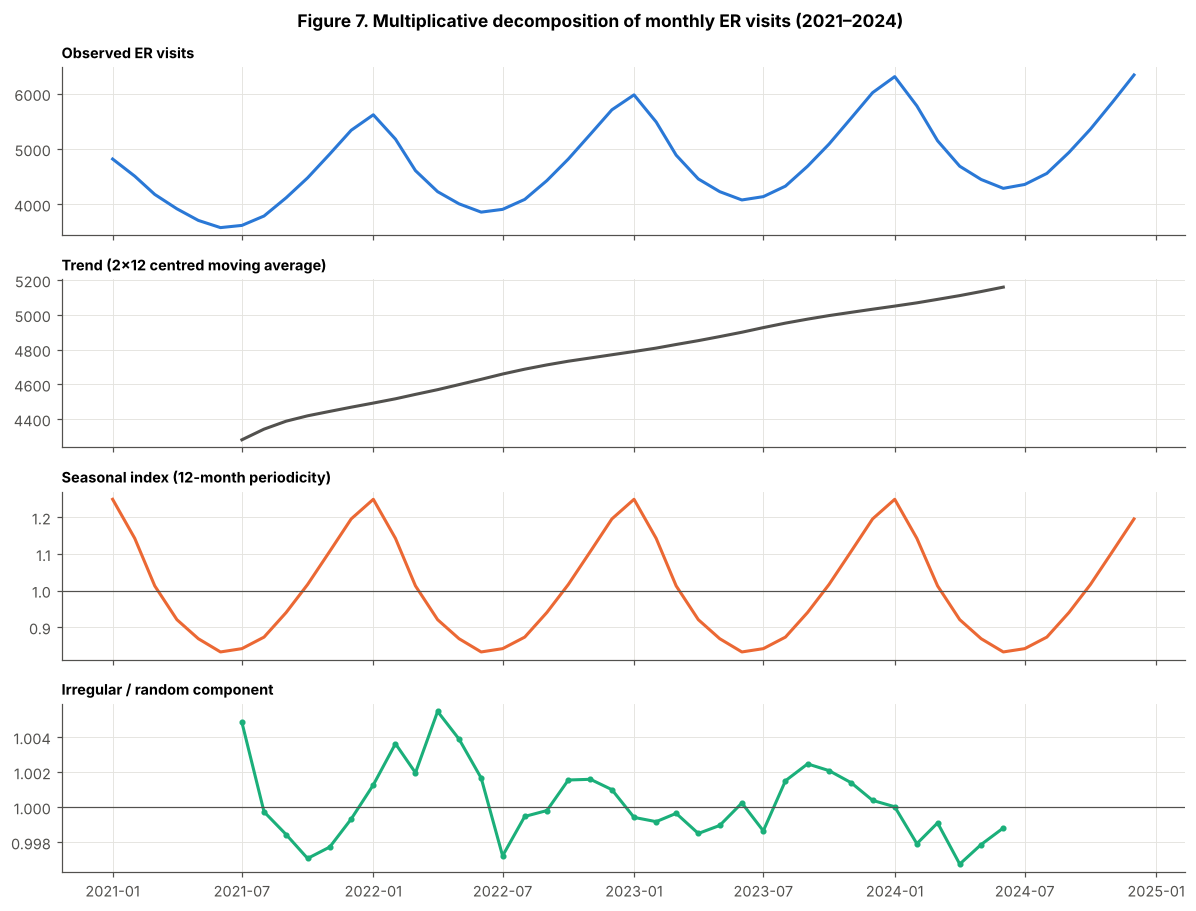

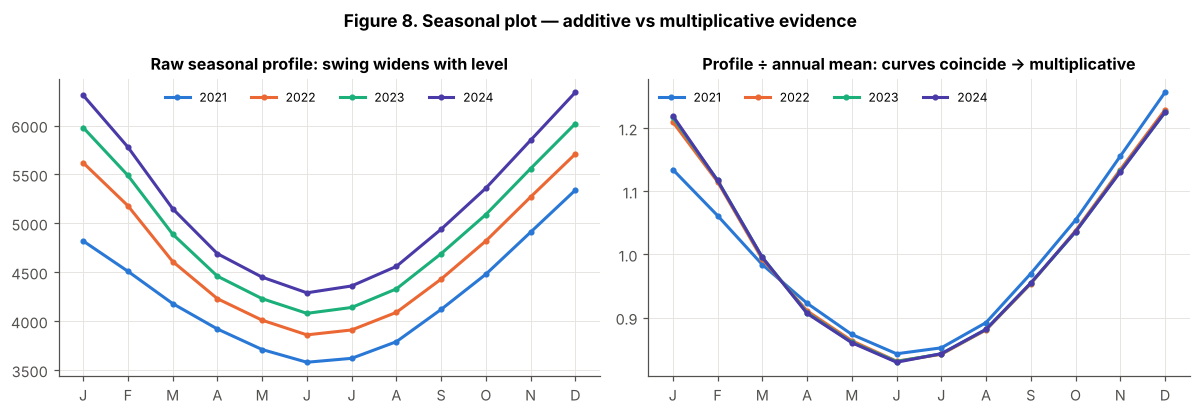

In [22]:
fig, axes = plt.subplots(4, 1, figsize=(11, 8.4), sharex=True)
for ax, s, ttl, col in zip(axes, [y, dec_mul.trend, dec_mul.seasonal, dec_mul.resid], ['Observed ER visits','Trend (2×12 centred moving average)','Seasonal index (12-month periodicity)','Irregular / random component'], [BLUE, INK2, ORANGE, AQUA]):
    ax.plot(s.index, s, color=col, marker='o' if ttl.startswith('Irr') else None, ms=3); ax.set_title(ttl, loc='left', fontsize=9.5)
axes[2].axhline(1, color=INK2, lw=.8); axes[3].axhline(1, color=INK2, lw=.8)
fig.suptitle('Figure 7. Multiplicative decomposition of monthly ER visits (2021–2024)', fontweight='bold'); fig.tight_layout()
save(fig, 'fig07_decomposition.png'); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
cols = [BLUE, ORANGE, AQUA, VIOLET]; mlab = ['J','F','M','A','M','J','J','A','S','O','N','D']
for c, yr in zip(cols, range(2021, 2025)):
    s = y[str(yr)].values; ax[0].plot(range(1,13), s, color=c, marker='o', ms=3, label=str(yr)); ax[1].plot(range(1,13), s/s.mean(), color=c, marker='o', ms=3, label=str(yr))
ax[0].set_title('Raw seasonal profile: swing widens with level'); ax[1].set_title('Profile ÷ annual mean: curves coincide → multiplicative')
for a in ax: a.set_xticks(range(1,13)); a.set_xticklabels(mlab); a.legend(ncol=4, fontsize=8)
fig.suptitle('Figure 8. Seasonal plot — additive vs multiplicative evidence', fontweight='bold'); fig.tight_layout()
save(fig, 'fig08_seasonal_plot.png'); plt.show()

### 3.2 Simple moving averages (3- and 6-month)

,Actual,SMA3,SMA6,SMA3_forecast,SMA6_forecast
Date,,,,,
2024-05-01,4450.0,4763.3,5400.0,5206.7,5585.0
2024-06-01,4290.0,4476.7,5111.7,4763.3,5400.0
2024-07-01,4360.0,4366.7,4786.7,4476.7,5111.7
2024-08-01,4560.0,4403.3,4583.3,4366.7,4786.7
2024-09-01,4940.0,4620.0,4548.3,4403.3,4583.3
2024-10-01,5360.0,4953.3,4660.0,4620.0,4548.3
2024-11-01,5850.0,5383.3,4893.3,4953.3,4660.0
2024-12-01,6340.0,5850.0,5235.0,5383.3,4893.3


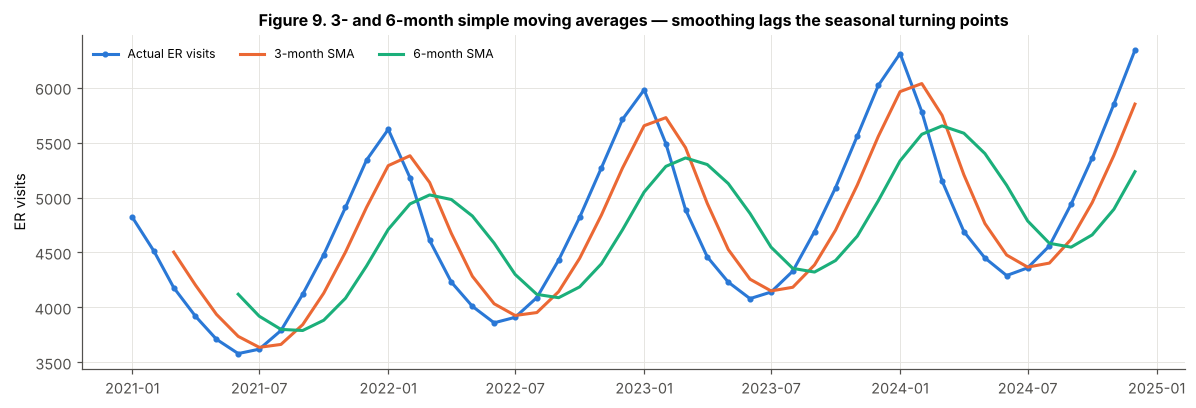

In [23]:
sma = pd.DataFrame({'Actual':y, 'SMA3':y.rolling(3).mean(), 'SMA6':y.rolling(6).mean()})
sma['SMA3_forecast'] = sma.SMA3.shift(1); sma['SMA6_forecast'] = sma.SMA6.shift(1)    # one-step-ahead forecast = average of the previous k months
display(sma.tail(8).round(1))
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(y.index, y, color=BLUE, marker='o', ms=3, label='Actual ER visits')
ax.plot(sma.index, sma.SMA3, color=ORANGE, label='3-month SMA'); ax.plot(sma.index, sma.SMA6, color=AQUA, label='6-month SMA')
ax.set_title('Figure 9. 3- and 6-month simple moving averages — smoothing lags the seasonal turning points'); ax.legend(ncol=3, fontsize=8); ax.set_ylabel('ER visits')
fig.tight_layout(); save(fig, 'fig09_sma.png'); plt.show()

### 3.3 Holt-Winters exponential smoothing (level, trend, multiplicative seasonality)
A transparent implementation is used so that every step can be reproduced cell-by-cell in the Excel workbook:

* Level: $L_t = \alpha\,\frac{Y_t}{S_{t-12}} + (1-\alpha)(L_{t-1}+T_{t-1})$
* Trend: $T_t = \beta\,(L_t - L_{t-1}) + (1-\beta)\,T_{t-1}$
* Season: $S_t = \gamma\,\frac{Y_t}{L_t} + (1-\gamma)\,S_{t-12}$
* Forecast: $\hat Y_{t+h} = (L_t + hT_t)\,S_{t+h-12}$

Initial seasonal indices come from the ratio-to-moving-average decomposition; initial level and trend from a linear fit to the deseasonalised series.
α, β, γ are chosen to minimise the in-sample one-step-ahead SSE (bounded 0.01–0.99). The statsmodels implementation is fitted as a cross-check.

In [24]:
def hw_init(y, L=12):
    d = seasonal_decompose(pd.Series(np.asarray(y)), model='multiplicative', period=L)
    S = np.asarray(d.seasonal[:L]); ds = np.asarray(y)/np.resize(S, len(y))
    slope, intercept = np.polyfit(np.arange(1, len(y)+1), ds, 1)
    return intercept, slope, S
def hw_run(y, a, b, g, l0, t0, S0, h=0, L=12):
    y = np.asarray(y, float); l, t, s = l0, t0, list(S0); fit, lv, tr = [], [], []
    for i in range(len(y)):
        si = s[i]; fit.append((l+t)*si)
        ln = a*y[i]/si + (1-a)*(l+t); t = b*(ln-l) + (1-b)*t; s.append(g*y[i]/ln + (1-g)*si); l = ln; lv.append(l); tr.append(t)
    fc = np.array([(l + k*t)*s[len(y)+(k-1) % L] for k in range(1, h+1)])
    return np.array(fit), fc, dict(level=np.array(lv), trend=np.array(tr), season=np.array(s))
def hw_fit(y):
    l0, t0, S0 = hw_init(y); best = None
    obj = lambda p: np.sum((np.asarray(y) - hw_run(y, *p, l0, t0, S0)[0])**2)
    for a in (.1,.3,.6):
        for b in (.05,.2):
            for g in (.05,.3):
                r = minimize(obj, [a,b,g], bounds=[(.01,.99)]*3, method='L-BFGS-B')
                if best is None or r.fun < best.fun: best = r
    return dict(alpha=best.x[0], beta=best.x[1], gamma=best.x[2], l0=l0, t0=t0, S0=S0, sse=best.fun)
def mape(a, f): a, f = np.asarray(a), np.asarray(f); return np.mean(np.abs((a-f)/a))*100
def rmse(a, f): a, f = np.asarray(a), np.asarray(f); return np.sqrt(np.mean((a-f)**2))
def mae(a, f): return np.mean(np.abs(np.asarray(a)-np.asarray(f)))
train, test = y[:'2023-12'], y['2024-01':]
P_tr = hw_fit(train.values)
fit_tr, fc_te, _ = hw_run(train.values, P_tr['alpha'], P_tr['beta'], P_tr['gamma'], P_tr['l0'], P_tr['t0'], P_tr['S0'], h=12)
print({k: (round(v,4) if np.isscalar(v) else np.round(v,4)) for k,v in P_tr.items()})

{'alpha': np.float64(0.99), 'beta': np.float64(0.01), 'gamma': np.float64(0.4401), 'l0': np.float64(4088.0517), 't0': np.float64(28.003), 'S0': array([1.2491, 1.1436, 1.0131, 0.922 , 0.8694, 0.8328, 0.8419, 0.8722,
       0.939 , 1.0155, 1.1062, 1.1953]), 'sse': np.float64(145652.1328)}


### 3.4 Out-of-sample evaluation: train Jan 2021 – Dec 2023 (36 months), test Jan – Dec 2024 (12 months)

In [25]:
sm_add = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=12, initialization_method='estimated').fit()
sm_mul = ExponentialSmoothing(train, trend='add', seasonal='mul', seasonal_periods=12, initialization_method='estimated').fit()
P_add = None
fc = pd.DataFrame({'Actual 2024':test.values,
    'SMA3 (flat, 12-step)':np.repeat(train[-3:].mean(), 12), 'SMA6 (flat, 12-step)':np.repeat(train[-6:].mean(), 12),
    'SMA3 (rolling 1-step)':sma.SMA3_forecast['2024'].values, 'SMA6 (rolling 1-step)':sma.SMA6_forecast['2024'].values,
    'Seasonal naïve':y.shift(12)['2024'].values,
    'HW additive (statsmodels)':sm_add.forecast(12).values, 'HW multiplicative (statsmodels)':sm_mul.forecast(12).values,
    'HW multiplicative (selected)':fc_te}, index=test.index)
acc = pd.DataFrame({m: {'MAPE %':mape(fc['Actual 2024'], fc[m]), 'RMSE':rmse(fc['Actual 2024'], fc[m]), 'MAE':mae(fc['Actual 2024'], fc[m]),
                        'Bias (mean error)':np.mean(fc[m]-fc['Actual 2024'])} for m in fc.columns[1:]}).T.sort_values('MAPE %')
display(acc.round(2)); display(fc.round(0))

,MAPE %,RMSE,MAE,Bias (mean error)
HW multiplicative (selected),0.79,43.39,40.41,40.41
HW multiplicative (statsmodels),0.95,57.20,49.47,-14.83
Seasonal naïve,5.02,262.87,260.00,-260.00
HW additive (statsmodels),5.24,274.63,253.04,250.54
"SMA6 (flat, 12-step)",11.65,743.40,625.00,-201.67
SMA3 (rolling 1-step),12.07,701.56,629.17,-50.28
"SMA3 (flat, 12-step)",14.95,811.74,725.56,383.33
SMA6 (rolling 1-step),16.40,936.65,850.00,-81.67


,Actual 2024,"SMA3 (flat, 12-step)","SMA6 (flat, 12-step)",SMA3 (rolling 1-step),SMA6 (rolling 1-step),Seasonal naïve,HW additive (statsmodels),HW multiplicative (statsmodels),HW multiplicative (selected)
Date,,,,,,,,,
2024-01-01,6310.0,5557.0,4972.0,5557.0,4972.0,5980.0,6295.0,6311.0,6324.0
2024-02-01,5780.0,5557.0,4972.0,5963.0,5333.0,5490.0,5882.0,5808.0,5823.0
2024-03-01,5150.0,5557.0,4972.0,6037.0,5575.0,4890.0,5382.0,5202.0,5187.0
2024-04-01,4690.0,5557.0,4972.0,5747.0,5652.0,4460.0,5025.0,4765.0,4745.0
2024-05-01,4450.0,5557.0,4972.0,5207.0,5585.0,4230.0,4805.0,4489.0,4498.0
2024-06-01,4290.0,5557.0,4972.0,4763.0,5400.0,4080.0,4662.0,4303.0,4331.0
2024-07-01,4360.0,5557.0,4972.0,4477.0,5112.0,4140.0,4712.0,4337.0,4401.0
2024-08-01,4560.0,5557.0,4972.0,4367.0,4787.0,4330.0,4892.0,4516.0,4584.0
2024-09-01,4940.0,5557.0,4972.0,4403.0,4583.0,4690.0,5235.0,4878.0,4961.0


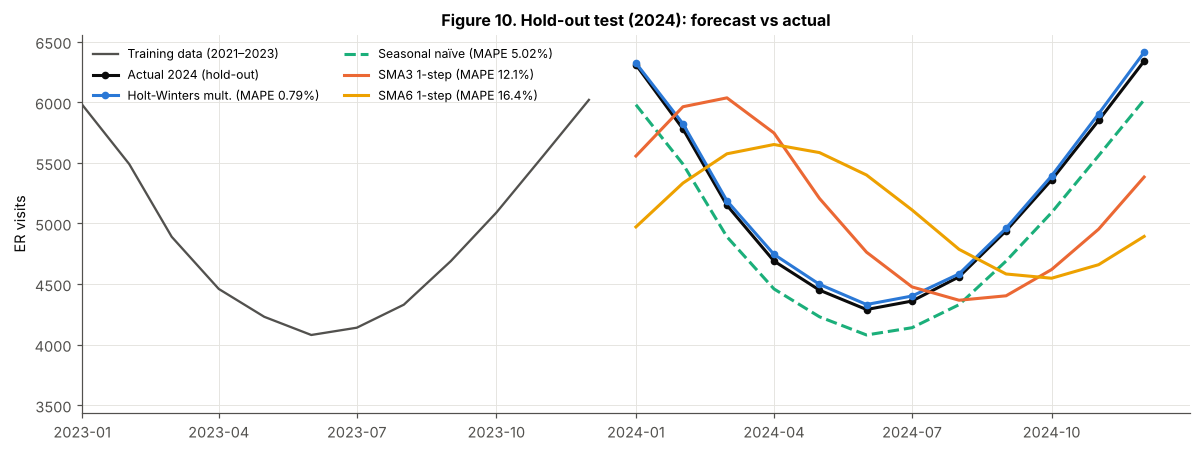

In [26]:
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(train.index, train, color=INK2, lw=1.5, label='Training data (2021–2023)')
ax.plot(test.index, test, color=INK, marker='o', ms=4, label='Actual 2024 (hold-out)')
ax.plot(test.index, fc['HW multiplicative (selected)'], color=BLUE, marker='o', ms=4, label=f"Holt-Winters mult. (MAPE {acc.loc['HW multiplicative (selected)','MAPE %']:.2f}%)")
ax.plot(test.index, fc['Seasonal naïve'], color=AQUA, ls='--', label=f"Seasonal naïve (MAPE {acc.loc['Seasonal naïve','MAPE %']:.2f}%)")
ax.plot(test.index, fc['SMA3 (rolling 1-step)'], color=ORANGE, label=f"SMA3 1-step (MAPE {acc.loc['SMA3 (rolling 1-step)','MAPE %']:.1f}%)")
ax.plot(test.index, fc['SMA6 (rolling 1-step)'], color=YELLOW, label=f"SMA6 1-step (MAPE {acc.loc['SMA6 (rolling 1-step)','MAPE %']:.1f}%)")
ax.set_xlim(pd.Timestamp('2023-01-01'), pd.Timestamp('2024-12-31')); ax.set_ylabel('ER visits'); ax.legend(fontsize=8, ncol=2, loc='upper left')
ax.set_title('Figure 10. Hold-out test (2024): forecast vs actual')
fig.tight_layout(); save(fig, 'fig10_holdout.png'); plt.show()

### 3.5 Final model on all 48 months and 12-month forecast for 2025
Prediction intervals are empirical: the model is re-estimated at every forecast origin from month 24 to month 47 (rolling-origin cross-validation) and the root-mean-square *relative* error at each horizon h = 1…12 sets the 80% / 95% bands.

In [27]:
def rolling_origin_errors(series, first_origin=24, H=12):
    # Time-series cross-validation: refit at every origin from month 24 and record relative h-step errors
    v = series.values.astype(float); E = {h: [] for h in range(1, H+1)}
    for o in range(first_origin, len(v)):
        P = hw_fit(v[:o]); _, f, _ = hw_run(v[:o], P['alpha'], P['beta'], P['gamma'], P['l0'], P['t0'], P['S0'], h=H)
        for h in range(1, H+1):
            if o+h-1 < len(v): E[h].append(v[o+h-1]/f[h-1] - 1)
    return E
def hw_forecast_with_pi(series, h=12):
    P = hw_fit(series.values); fit, f, st = hw_run(series.values, P['alpha'], P['beta'], P['gamma'], P['l0'], P['t0'], P['S0'], h=h)
    E = rolling_origin_errors(series, H=h)
    sig = np.array([np.sqrt(np.mean(np.square(E[k]))) for k in range(1, h+1)])   # RMS relative error by horizon
    sig = np.maximum.accumulate(sig)                                                  # uncertainty cannot shrink with horizon
    idx = pd.date_range(series.index[-1] + pd.offsets.MonthBegin(1), periods=h, freq='MS')
    out = pd.DataFrame({'Forecast':f, 'Lo95':f*(1-1.96*sig), 'Lo80':f*(1-1.2816*sig), 'Hi80':f*(1+1.2816*sig), 'Hi95':f*(1+1.96*sig), 'RelErr_SD_%':sig*100, 'n_origins':[len(E[k]) for k in range(1,h+1)]}, index=idx)
    return out, P, fit
fc25, P_full, fit_full = hw_forecast_with_pi(y)
print('Final parameters:', {k: round(P_full[k], 4) for k in ['alpha','beta','gamma','l0','t0']})
print('In-sample MAPE (2022-2024): %.2f%%  RMSE: %.1f' % (mape(y[12:], fit_full[12:]), rmse(y[12:], fit_full[12:])))
icu25, P_icu, fit_icu = hw_forecast_with_pi(df.ICU_Util_Rate.astype(float))
flu25, P_flu, _ = hw_forecast_with_pi(df.Flu_Resp_Cases.astype(float))
fc25['Days'] = fc25.index.days_in_month; fc25['Daily ER visits'] = fc25.Forecast/fc25.Days
fc25['ICU % (forecast)'] = icu25.Forecast; fc25['ICU % Hi80'] = icu25.Hi80; fc25['Flu cases (forecast)'] = flu25.Forecast
fc25['vs 2024 same month %'] = (fc25.Forecast/y['2024'].values - 1)*100
display(fc25.round(1))
print(f"2025 total ER visits: {fc25.Forecast.sum():,.0f} (2024 actual {y['2024'].sum():,.0f}; growth {(fc25.Forecast.sum()/y['2024'].sum()-1)*100:.1f}%)")

Final parameters: {'alpha': np.float64(0.99), 'beta': np.float64(0.01), 'gamma': np.float64(0.1875), 'l0': np.float64(4123.89), 't0': np.float64(25.4767)}
In-sample MAPE (2022-2024): 0.17%  RMSE: 9.9


,Forecast,Lo95,Lo80,Hi80,Hi95,RelErr_SD_%,n_origins,Days,Daily ER visits,ICU % (forecast),ICU % Hi80,Flu cases (forecast),vs 2024 same month %
2025-01-01,6654.7,6612.6,6627.2,6682.2,6696.7,0.3,24,31,214.7,101.4,102.0,2333.3,5.5
2025-02-01,6115.6,6054.3,6075.5,6155.8,6177.0,0.5,23,28,218.4,94.0,94.5,1996.1,5.8
2025-03-01,5446.8,5375.0,5399.8,5493.8,5518.6,0.7,22,31,175.7,85.2,85.8,1505.8,5.8
2025-04-01,4973.8,4892.4,4920.6,5027.1,5055.3,0.8,21,30,165.8,78.2,78.8,1197.9,6.1
2025-05-01,4714.1,4630.1,4659.2,4769.1,4798.1,0.9,20,31,152.1,74.1,74.7,1054.3,5.9
2025-06-01,4538.8,4451.4,4481.7,4596.0,4626.3,1.0,19,30,151.3,71.0,71.7,980.2,5.8
2025-07-01,4608.9,4500.9,4538.3,4679.5,4716.9,1.2,18,31,148.7,72.0,73.0,1028.3,5.7
2025-08-01,4803.7,4688.5,4728.4,4878.9,4918.8,1.2,17,31,155.0,75.9,77.0,1132.9,5.3
2025-09-01,5197.6,5063.3,5109.8,5285.4,5331.9,1.3,16,30,173.3,81.4,82.6,1418.6,5.2
2025-10-01,5645.3,5482.0,5538.5,5752.1,5808.6,1.5,15,31,182.1,87.1,88.5,1657.7,5.3


2025 total ER visits: 65,574 (2024 actual 62,080; growth 5.6%)


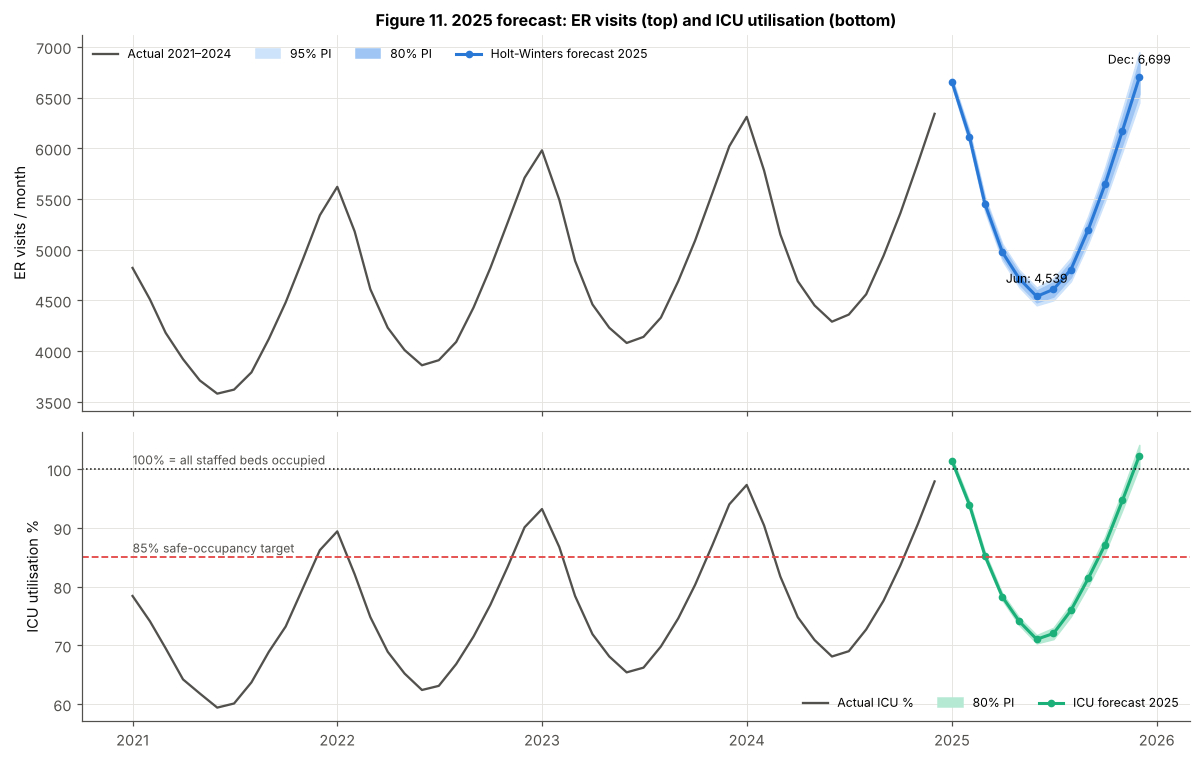

In [28]:
fig, ax = plt.subplots(2, 1, figsize=(11, 7), sharex=True, gridspec_kw={'height_ratios':[1.3,1]})
ax[0].plot(y.index, y, color=INK2, lw=1.5, label='Actual 2021–2024')
ax[0].fill_between(fc25.index, fc25.Lo95, fc25.Hi95, color='#cde2fb', label='95% PI'); ax[0].fill_between(fc25.index, fc25.Lo80, fc25.Hi80, color='#9ec5f4', label='80% PI')
ax[0].plot(fc25.index, fc25.Forecast, color=BLUE, marker='o', ms=4, label='Holt-Winters forecast 2025')
for d in [fc25.Forecast.idxmax(), fc25.Forecast.idxmin()]:
    ax[0].annotate(f"{d:%b}: {fc25.loc[d,'Forecast']:,.0f}", (d, fc25.loc[d,'Forecast']), xytext=(0,9), textcoords='offset points', ha='center', fontsize=8)
ax[0].set_ylabel('ER visits / month'); ax[0].legend(fontsize=8, ncol=4, loc='upper left'); ax[0].set_title('Figure 11. 2025 forecast: ER visits (top) and ICU utilisation (bottom)')
ax[1].plot(df.index, df.ICU_Util_Rate, color=INK2, lw=1.5, label='Actual ICU %')
ax[1].fill_between(icu25.index, icu25.Lo80, icu25.Hi80, color='#b6e9d4', label='80% PI'); ax[1].plot(icu25.index, icu25.Forecast, color=AQUA, marker='o', ms=4, label='ICU forecast 2025')
ax[1].axhline(85, color=RED, ls='--', lw=1.2); ax[1].axhline(100, color=INK, ls=':', lw=1)
ax[1].text(df.index[0], 85.8, '85% safe-occupancy target', fontsize=8, color=INK2); ax[1].text(df.index[0], 100.8, '100% = all staffed beds occupied', fontsize=8, color=INK2)
ax[1].set_ylabel('ICU utilisation %'); ax[1].legend(fontsize=8, loc='lower right', ncol=3)
fig.tight_layout(); save(fig, 'fig11_forecast_2025.png'); plt.show()

# Section 4 — Translating the forecast into capacity, staffing and budget

In [29]:
plan = pd.DataFrame(index=fc25.index)
plan['ER forecast'] = fc25.Forecast; plan['ER P90 (Hi80)'] = fc25.Hi80
plan['Staffing index vs 2024 avg month'] = fc25.Forecast / y['2024'].mean()
plan['Daily visits (P90)'] = fc25.Hi80 / fc25.Days
plan['ICU forecast %'] = icu25.Forecast; plan['ICU P90 %'] = icu25.Hi80
plan['Extra ICU beds needed to hold 85% (% of current)'] = np.clip(icu25.Forecast/85 - 1, 0, None)*100
plan['Extra ICU beds at P90 (% of current)'] = np.clip(icu25.Hi80/85 - 1, 0, None)*100
plan['Expenditure forecast $'] = exp_m.params.iloc[0] + exp_m.params.iloc[1]*fc25.Forecast
flat = plan['Expenditure forecast $'].mean()
plan['Above flat monthly budget $'] = np.clip(plan['Expenditure forecast $'] - flat, 0, None)
display(plan.round(2))
print(f"2025 expenditure forecast: ${plan['Expenditure forecast $'].sum():,.0f}; flat monthly budget ${flat:,.0f}")
print(f"Winter-surge reserve required (sum of above-flat months): ${plan['Above flat monthly budget $'].sum():,.0f}")
print(f"Months with forecast ICU > 85%: {list(plan.index[plan['ICU forecast %']>85].strftime('%b'))}")
print(f"Months with forecast ICU > 95%: {list(plan.index[plan['ICU forecast %']>95].strftime('%b'))}")

,ER forecast,ER P90 (Hi80),Staffing index vs 2024 avg month,Daily visits (P90),ICU forecast %,ICU P90 %,Extra ICU beds needed to hold 85% (% of current),Extra ICU beds at P90 (% of current),Expenditure forecast $,Above flat monthly budget $
2025-01-01,6654.68,6682.19,1.29,215.55,101.42,101.97,19.31,19.96,1630976.36,237956.48
2025-02-01,6115.65,6155.76,1.18,219.85,93.96,94.54,10.54,11.22,1523205.18,130185.30
2025-03-01,5446.79,5493.75,1.05,177.22,85.21,85.76,0.24,0.89,1389478.84,0.00
2025-04-01,4973.84,5027.11,0.96,167.57,78.23,78.78,0.00,0.00,1294920.30,0.00
2025-05-01,4714.12,4769.05,0.91,153.84,74.08,74.72,0.00,0.00,1242992.13,0.00
2025-06-01,4538.84,4596.01,0.88,153.20,71.03,71.73,0.00,0.00,1207948.13,0.00
2025-07-01,4608.92,4679.53,0.89,150.95,72.02,72.98,0.00,0.00,1221959.02,0.00
2025-08-01,4803.65,4878.93,0.93,157.38,75.94,76.97,0.00,0.00,1260892.92,0.00
2025-09-01,5197.56,5285.38,1.00,176.18,81.39,82.65,0.00,0.00,1339649.42,0.00
2025-10-01,5645.32,5752.12,1.09,185.55,87.14,88.49,2.52,4.11,1429171.86,36151.97


2025 expenditure forecast: $16,716,239; flat monthly budget $1,393,020
Winter-surge reserve required (sum of above-flat months): $793,298
Months with forecast ICU > 85%: ['Jan', 'Feb', 'Mar', 'Oct', 'Nov', 'Dec']
Months with forecast ICU > 95%: ['Jan', 'Dec']


In [30]:
# Scenario stress test: link the regression to the forecast. A severe respiratory season (+15% flu, as in 2022's +16%)
shock = 0.15
scen = pd.DataFrame({'Flu base':flu25.Forecast, 'ER base':fc25.Forecast}, index=fc25.index)
scen['Extra ER visits (+15% flu)'] = ref.params['Flu_Resp_Cases']*shock*scen['Flu base']
scen['ER severe season'] = scen['ER base'] + scen['Extra ER visits (+15% flu)']
scen['ICU severe %'] = icu25.Forecast*(scen['ER severe season']/scen['ER base'])
scen['Extra cost $'] = exp_m.params.iloc[1]*scen['Extra ER visits (+15% flu)']
display(scen.round(1))
print(f"Severe-season extra ER visits (year): {scen['Extra ER visits (+15% flu)'].sum():,.0f}; extra cost ${scen['Extra cost $'].sum():,.0f}; Jan ICU {scen.loc['2025-01-01','ICU severe %']:.1f}%")

# Export key results for the report and the workbook
R = dict(desc=desc.round(4).to_dict(), corr=corr.round(4).to_dict(), annual=annual.round(4).to_dict(), yoy=yoy.round(3).to_dict(),
    slr=dict(b0=slr.params.iloc[0], b1=slr.params.iloc[1], r2=slr.rsquared, adj=slr.rsquared_adj, F=slr.fvalue, se=float(np.sqrt(slr.mse_resid)), p=slr.pvalues.iloc[1], t=slr.tvalues.iloc[1], bse=slr.bse.iloc[1]),
    mlr=dict(params=mlr.params.to_dict(), p=mlr.pvalues.to_dict(), bse=mlr.bse.to_dict(), t=mlr.tvalues.to_dict(), r2=mlr.rsquared, adj=mlr.rsquared_adj, F=mlr.fvalue, Fp=mlr.f_pvalue, se=float(np.sqrt(mlr.mse_resid)), vif=vif_table(mlr).VIF.to_dict(), hac_p=dict(zip(mlr.model.exog_names, hac['MLR (full)'].pvalues))),
    ref=dict(params=ref.params.to_dict(), p=ref.pvalues.to_dict(), bse=ref.bse.to_dict(), t=ref.tvalues.to_dict(), r2=ref.rsquared, adj=ref.rsquared_adj, F=ref.fvalue, Fp=ref.f_pvalue, se=float(np.sqrt(ref.mse_resid)), vif=vif_table(ref).VIF.to_dict(), hac_p=dict(zip(ref.model.exog_names, hac['MLR (refined)'].pvalues)), std_beta=coef_table(ref)['Std Beta'].dropna().to_dict()),
    diag=diag.to_dict(), exp_model=dict(a=exp_m.params.iloc[0], b=exp_m.params.iloc[1], r2=exp_m.rsquared),
    amp=amp.to_dict(), seas_idx=seas_idx.to_dict(), acc=acc.to_dict(), P_tr={k:(v.tolist() if hasattr(v,'tolist') else v) for k,v in P_tr.items()},
    P_full={k:(v.tolist() if hasattr(v,'tolist') else v) for k,v in P_full.items()}, P_icu={k:(v.tolist() if hasattr(v,'tolist') else v) for k,v in P_icu.items()},
    holdout=fc.round(2).reset_index(drop=True).to_dict(orient='list'), fc25=fc25.round(3).reset_index(drop=True).to_dict(orient='list'), plan=plan.round(3).reset_index(drop=True).to_dict(orient='list'),
    icu25=icu25.round(3).reset_index(drop=True).to_dict(orient='list'), flu25=flu25.round(2).reset_index(drop=True).to_dict(orient='list'),
    sm_params=dict(add={k:float(v) for k,v in sm_add.params.items() if np.isscalar(v)}, mul={k:float(v) for k,v in sm_mul.params.items() if np.isscalar(v)}),
    scen=scen.round(2).reset_index(drop=True).to_dict(orient='list'), resid_max=float(anom.Resid_z.abs().max()), resid_pct_max=float(resid_pct.abs().max()))
json.dump(R, open('results.json','w'), default=float, indent=1); print('results.json written')

,Flu base,ER base,Extra ER visits (+15% flu),ER severe season,ICU severe %,Extra cost $
2025-01-01,2333.3,6654.7,573.7,7228.4,110.2,114696.1
2025-02-01,1996.1,6115.6,490.7,6606.4,101.5,98116.7
2025-03-01,1505.8,5446.8,370.2,5817.0,91.0,74016.2
2025-04-01,1197.9,4973.8,294.5,5268.4,82.9,58883.5
2025-05-01,1054.3,4714.1,259.2,4973.3,78.1,51823.6
2025-06-01,980.2,4538.8,241.0,4779.8,74.8,48180.8
2025-07-01,1028.3,4608.9,252.8,4861.7,76.0,50548.9
2025-08-01,1132.9,4803.7,278.5,5082.2,80.3,55687.0
2025-09-01,1418.6,5197.6,348.8,5546.3,86.8,69732.1
2025-10-01,1657.7,5645.3,407.6,6052.9,93.4,81486.5


Severe-season extra ER visits (year): 4,579; extra cost $915,559; Jan ICU 110.2%
results.json written


## Summary of analytical conclusions
* **Demand is seasonal, multiplicative and growing**: ER visits rose 21.8% from 2021 to 2024, with a stable winter/summer ratio of ≈ 1.48 and January the peak month.
* **Respiratory infection is the lead driver** (Adj. R² 0.975 alone); population density adds a structural ≈ 31 visits per index point; the calendar adds nothing once flu is known.
* **Holt-Winters (multiplicative) is the most accurate model** on the 2024 hold-out (MAPE < 1%), beating seasonal naïve (≈ 5%) and the SMAs (12–16%), which lag turning points by construction.
* **2025 outlook**: ≈ 65,600 ER visits (+5.6%), winter peaks of ≈ 6,650 (January) and ≈ 6,700 (December) and a June trough of ≈ 4,540. ICU utilisation is projected above the 85% target in six months (Oct–Mar) and above 100% of current staffed beds in January and December 2025 — the binding constraint for capacity planning.